In [1]:
import tensorflow as tf
from tensorflow import keras
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPooling2D, AvgPool2D

In [2]:
import numpy as np
import pandas as pd

In [3]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Expand to (batch, height, width, channels)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# Resize to 32×32
x_train = tf.image.resize(x_train, (32, 32)).numpy()
x_test = tf.image.resize(x_test, (32, 32)).numpy()

# Normalize to [0,1]
x_train = x_train / 255.0
x_test = x_test / 255.0

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
model = Sequential()
model.add(Conv2D(6, kernel_size = (5, 5),activation = 'tanh',padding = 'valid', input_shape=(32, 32, 1)))
model.add(AvgPool2D(pool_size = (2,2), padding='valid', strides=2))
model.add(Conv2D(16, kernel_size=(5, 5), activation = 'tanh', padding = 'valid'))
model.add(AvgPool2D(pool_size = (2, 2), padding='valid', strides=2))
model.add(Flatten())
model.add(Dense(120, activation = 'tanh'))
model.add(Dense(84, activation = 'tanh'))
model.add(Dense(10, activation = 'softmax'))



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 14, 14, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 5, 5, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,706 (241.04 KB)

 Trainable params: 61,706 (241.04 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [7]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.1
)

Epoch 1/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8284 - loss: 0.6218 - val_accuracy: 0.9648 - val_loss: 0.1314
Epoch 2/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9588 - loss: 0.1358 - val_accuracy: 0.9757 - val_loss: 0.0820
Epoch 3/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9738 - loss: 0.0867 - val_accuracy: 0.9808 - val_loss: 0.0717
Epoch 4/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9810 - loss: 0.0631 - val_accuracy: 0.9825 - val_loss: 0.0567
Epoch 5/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9868 - loss: 0.0456 - val_accuracy: 0.9830 - val_loss: 0.0592
Epoch 6/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9878 - loss: 0.0396 - val_accuracy: 0.9838 - val_loss: 0.0573
Epoch 7/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9911 - loss: 0.0292 - val_accuracy: 0.9853 - val_loss: 0.0543
Epoch 8/10
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9926 - loss: 0.0254 - val_accuracy: 0

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9823 - loss: 0.0573
Test Accuracy: 0.9860000014305115


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 722ms/step
Predicted digit = 9


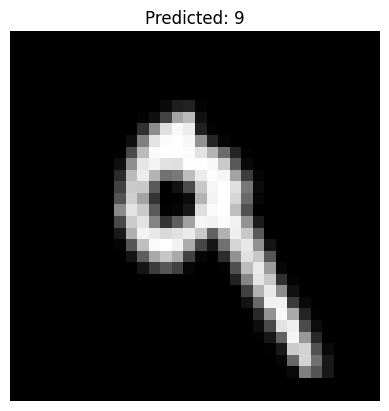

In [11]:
import matplotlib.pyplot as plt

idx = 7
img = x_test[idx] # img is already (32, 32, 1) and normalized

# Add batch dimension → (1, 32, 32, 1)
img_input = np.expand_dims(img, axis=0)

# ---- Predict ----
pred = model.predict(img_input)
digit = np.argmax(pred)

print("Predicted digit =", digit)

# ---- Show the image ----
plt.imshow(x_test[idx], cmap='gray')
plt.title(f"Predicted: {digit}")
plt.axis("off")
plt.show()